In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


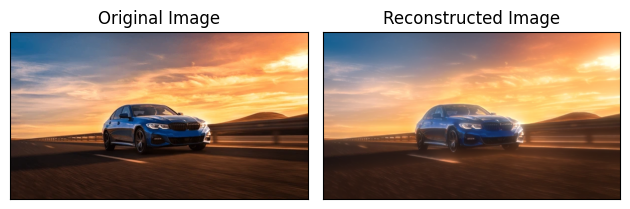

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

# Load your image
img = cv2.imread('/content/drive/MyDrive/opencv/bmw1.jpg')

# Define the number of pyramid levels
num_levels = 5 # You can change this value

# 1. Create Gaussian Pyramid
gp = [img]
for i in range(num_levels): # num_levels determines how many levels down you go
    img = cv2.pyrDown(img)
    gp.append(img)

# 2. Create Laplacian Pyramid
lp = [gp[num_levels-1]] # Smallest Gaussian level is the base of Laplacian
for i in range(num_levels-1, 0, -1):
    gaussian_expanded = cv2.pyrUp(gp[i])
    # Ensure sizes match before subtraction, as pyrUp might not perfectly restore original size
    if gaussian_expanded.shape != gp[i-1].shape:
        gaussian_expanded = cv2.resize(gaussian_expanded, (gp[i-1].shape[1], gp[i-1].shape[0]))

    laplacian = cv2.subtract(gp[i-1], gaussian_expanded)
    lp.append(laplacian)

# 3. Reconstruct the Image
reconstructed_img = lp[0] # Start with the smallest Laplacian level (which is the smallest Gaussian level)
for i in range(1, len(lp)):
    reconstructed_img = cv2.pyrUp(reconstructed_img)
    # Ensure sizes match before adding
    if reconstructed_img.shape != lp[i].shape:
        reconstructed_img = cv2.resize(reconstructed_img, (lp[i].shape[1], lp[i].shape[0]))

    reconstructed_img = cv2.add(reconstructed_img, lp[i])

# Display the original and reconstructed images side by side
plt.subplot(121), plt.imshow(cv2.cvtColor(cv2.imread('/content/drive/MyDrive/opencv/bmw1.jpg'), cv2.COLOR_BGR2RGB))
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(cv2.cvtColor(reconstructed_img, cv2.COLOR_BGR2RGB))
plt.title('Reconstructed Image'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()